# Forecasting Glucose Levels in Type 1 Diabetes Using Time-Series Approaches #

**Student Name:** Muhammad Umer Mehmood

**Student ID:** 23102319

**Supervisor:** Ralf Napiwotzki

**Submission Date:** 

### Regarding the Dataset

The [GlucoBench repository](https://github.com/IrinaStatsLab/GlucoBench), which gathers comprehensive and long-term records of continuous glucose monitoring (CGM) data, is the source of this dataset. Both descriptive and predictive studies are made possible by the data's integration of glucose levels with clinical, lifestyle, and demographic data.

A single glucose measurement from a particular patient at a particular time point is represented by each row.

**Key Features:**
- **id:** Each patient's unique identification number
- **gl:** The target variable's blood glucose reading
- **time:** The glucose measurement's timestamp

**The demographics:**
Gender, income, education level, race/ethnicity, and marital status

**Clinical Background:**
Diabetes duration, comorbidities, hypertension, and complications

**Lifestyle Elements:**
Alcohol consumption, exercise routines, and dietary supplements

**Drugs**
Binary indicators for frequently prescribed drugs

### The Analysis's Objective

- Determine the glucose patterns unique to each patient.
- Conduct sophisticated statistical and visual analysis
- Create and assess forecasting models to aid in controlling of diabetes
- Provide practical insights that connect glycemic control to clinical,     lifestyle, and demographic aspects.

In [1]:
import os
import random
import itertools
import numpy as np
import pandas as pd

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Statistics
# ==============================
from scipy.stats import skew

# ==============================
# Scikit-learn
# ==============================
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
)

# ==============================
# TensorFlow / Keras
# ==============================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Conv1D, Flatten, Dense, Dropout, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

2026-03-03 00:16:17.049445: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772496977.252267      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772496977.312708      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772496977.759233      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772496977.759287      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772496977.759290      55 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv('/kaggle/input/datasets/umercheena/glucose-checker-meter/weinstock.csv')

In [3]:
df.head()

,id,gl,time,Gender,Race,EduLevel,AnnualInc,MaritalStatus,DaysWkEx,DaysWkDrinkAlc,...,Type I diabetes mellitus,Aspirin,Simvastatin,Lisinopril,Vitamin D,Multivitamin preparation,Omeprazole,atorvastatin,Synthroid,vitamin D3
0,199,200.0,1900-01-01 17:49:32,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,199,195.0,1900-01-01 17:54:32,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,199,236.0,1900-01-01 20:29:31,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,199,210.0,1900-01-01 20:34:31,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,199,196.0,1900-01-01 20:39:31,F,White,7,2,Married,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [4]:
df.columns.tolist()

['id',
 'gl',
 'time',
 'Gender',
 'Race',
 'EduLevel',
 'AnnualInc',
 'MaritalStatus',
 'DaysWkEx',
 'DaysWkDrinkAlc',
 'DaysMonBingeAlc',
 'T1DDiagAge',
 'NumHospDKA',
 'NumSHSinceT1DDiag',
 'InsDeliveryMethod',
 'UnitsInsTotal',
 'NumMeterCheckDay',
 'Height',
 'Weight',
 'Hypertension',
 'Hyperlipidemia',
 'Hypothyroidism',
 'Depression',
 'Coronary artery disease',
 'Diabetic peripheral neuropathy',
 'Dyslipidemia',
 'Chronic kidney disease',
 'Osteoporosis',
 'Proliferative diabetic retinopathy',
 'Hypercholesterolemia',
 'Erectile dysfunction',
 'Type I diabetes mellitus',
 'Aspirin',
 'Simvastatin',
 'Lisinopril',
 'Vitamin D',
 'Multivitamin preparation',
 'Omeprazole',
 'atorvastatin',
 'Synthroid',
 'vitamin D3']

In [5]:
def check_insulin_df(df, head=5):
    """
    Comprehensive summary of clinical/biometric data for insulin forecasting.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    head : int, default=5
        Number of rows to show from head and tail.
        
    Returns
    -------
    None. Prints info to screen.
    """
    import pandas as pd
    # --- Validation ---
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")
    if not isinstance(head, int) or head < 1:
        raise ValueError("head must be a positive integer")
    
    def print_section_header(number, title):
        print(f"\n{number} {title}")
        print("━" * 60)

    print("\n🩸 CGM Dataset Quick Overview")
    print("━" * 60)

    # 1. Basic Info
    print_section_header("1️⃣", "Basic Information")
    print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
    print(f"Target column: 'unitsinstotal'")
    print(f"Timestamp column: 'time'")
    
    # 2. Data Types, Missing, Null
    print_section_header("2️⃣", "Column Types & Null Values")
    dtype_df = pd.DataFrame({
        'Type': df.dtypes,
        'Non-Null': df.count(),
        'Null': df.isnull().sum(),
        'Null %': (df.isnull().sum() / len(df) * 100).round(2).astype(str) + '%'
    }).reset_index().rename(columns={'index': 'Column'})
    print(dtype_df.to_string(index=False))

    # 3. Unique values for categorical features
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print_section_header("3️⃣", "Categorical Feature Cardinality")
        for col in categorical_cols:
            print(f"- {col}: {df[col].nunique()} unique values | Top: {df[col].unique()[:5]}")
    
    # 4. Head and Tail
    print_section_header("4️⃣", f"First {head} Rows")
    print(df.head(head))
    print_section_header("5️⃣", f"Last {head} Rows")
    print(df.tail(head))
    
    # 5. Numeric Stats
    numeric_cols = df.select_dtypes(include=[int, float]).columns
    if len(numeric_cols) > 0:
        print_section_header("6️⃣", "Numeric Summary (including outlier quantiles)")
        desc = df[numeric_cols].describe([0, .05, .5, .95, .99, 1]).T.round(2)
        desc['count'] = desc['count'].astype(int)
        print(desc)
        print("\nPotential outliers (values at 0.99 or 1.00 quantile) are flagged above.")

    # 6. Memory Usage
    print_section_header("7️⃣", "Memory Usage")
    mem_total = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Total: {mem_total:.2f} MB")
    print("By column (MB):")
    print(df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2)
    print("━" * 60)
    
check_insulin_df(df, head=10)


🩸 CGM Dataset Quick Overview
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1️⃣ Basic Information
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Rows: 647,858 | Columns: 41
Target column: 'unitsinstotal'
Timestamp column: 'time'

2️⃣ Column Types & Null Values
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                            Column    Type  Non-Null  Null Null %
                                id   int64    647858     0   0.0%
                                gl float64    647858     0   0.0%
                              time  object    647858     0   0.0%
                            Gender  object    647858     0   0.0%
                              Race  object    647858     0   0.0%
                          EduLevel   int64    647858     0   0.0%
                         AnnualInc   int64    647858     0   0.0%
                     MaritalStatus  object    647858     0   0.0%
                          DaysWkEx float64    647858  

In [6]:
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

# 2. Identify and handle missing values
# Show % missing per column
print("Missing value percentage per column:")
print(df.isnull().mean().sort_values(ascending=False) * 100)

# Example: Drop rows with missing glucose or time (adjust as needed)
df = df.dropna(subset=['gl', 'time'])

# Optionally, fill missing for other columns (customize as needed)
# df['some_column'] = df['some_column'].fillna(df['some_column'].median())

# 3. Correct data types (convert time to datetime)
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# 4. Remove or flag duplicates
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows.")

# 5. Address outliers and erroneous values in 'gl'
# Example: Remove glucose values outside 1st–99th percentile as outliers
q_low = df['gl'].quantile(0.01)
q_high = df['gl'].quantile(0.99)
df = df[(df['gl'] >= q_low) & (df['gl'] <= q_high)]

print("Data cleaned. Shape after cleaning:", df.shape)

Missing value percentage per column:
id                                    0.0
gl                                    0.0
time                                  0.0
gender                                0.0
race                                  0.0
edulevel                              0.0
annualinc                             0.0
maritalstatus                         0.0
dayswkex                              0.0
dayswkdrinkalc                        0.0
daysmonbingealc                       0.0
t1ddiagage                            0.0
numhospdka                            0.0
numshsincet1ddiag                     0.0
insdeliverymethod                     0.0
unitsinstotal                         0.0
nummetercheckday                      0.0
height                                0.0
weight                                0.0
hypertension                          0.0
hyperlipidemia                        0.0
hypothyroidism                        0.0
depression                            0

In [7]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    """
    Returns lists of categorical, numerical, and cardinal categorical variables for clinical/biometric datasets.
    
    Parameters
    ----------
    dataframe : pd.DataFrame
        Input dataset.
    cat_th : int, default=10
        Threshold for numeric-but-categorical detection.
    car_th : int, default=20
        Threshold for cardinality in categorical columns.
        
    Returns
    -------
    cat_cols : list
        Categorical variable names
    num_cols : list
        Numeric variable names
    cat_but_car : list
        Categorical but cardinal variable names
    """
    # 1. Categorical
    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object", "bool"]]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes in [int, float]]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   str(dataframe[col].dtypes) in ["category", "object"]]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]
    
    # 2. Numeric
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes in [int, float]]
    num_cols = [col for col in num_cols if col not in cat_cols]

    print("\n📊 Variable Analysis Report")
    print("━" * 50)
    print(f"Observations: {dataframe.shape[0]:,} | Variables: {dataframe.shape[1]}")

    print("\n- Categorical Variables:", len(cat_cols))
    print("- Numeric Variables:", len(num_cols))
    print("- Cardinal Categorical Variables:", len(cat_but_car))
    print("- Numeric but Categorical Variables:", len(num_but_cat))

    if len(cat_cols) > 0:
        print("\nCategorical:")
        for col in cat_cols:
            print(f"  ▫️ {col} ({dataframe[col].nunique()} unique)")
    if len(num_cols) > 0:
        print("\nNumeric:")
        for col in num_cols:
            print(f"  ▫️ {col} ({dataframe[col].nunique()} unique)")
    if len(num_but_cat) > 0:
        print("\nNumeric but Categorical:")
        for col in num_but_cat:
            print(f"  ▫️ {col} ({dataframe[col].nunique()} unique)")
    if len(cat_but_car) > 0:
        print("\nCardinal Categorical:")
        for col in cat_but_car:
            print(f"  ▫️ {col} ({dataframe[col].nunique()} unique)")
    print("━" * 50)
    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)


📊 Variable Analysis Report
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Observations: 647,858 | Variables: 41

- Categorical Variables: 31
- Numeric Variables: 9
- Cardinal Categorical Variables: 0
- Numeric but Categorical Variables: 27

Categorical:
  ▫️ gender (2 unique)
  ▫️ race (5 unique)
  ▫️ maritalstatus (8 unique)
  ▫️ insdeliverymethod (2 unique)
  ▫️ annualinc (8 unique)
  ▫️ dayswkex (8 unique)
  ▫️ daysmonbingealc (4 unique)
  ▫️ numhospdka (3 unique)
  ▫️ numshsincet1ddiag (8 unique)
  ▫️ hypertension (2 unique)
  ▫️ hyperlipidemia (2 unique)
  ▫️ hypothyroidism (2 unique)
  ▫️ depression (2 unique)
  ▫️ coronary_artery_disease (2 unique)
  ▫️ diabetic_peripheral_neuropathy (2 unique)
  ▫️ dyslipidemia (2 unique)
  ▫️ chronic_kidney_disease (2 unique)
  ▫️ osteoporosis (2 unique)
  ▫️ proliferative_diabetic_retinopathy (2 unique)
  ▫️ hypercholesterolemia (2 unique)
  ▫️ erectile_dysfunction (2 unique)
  ▫️ type_i_diabetes_mellitus (2 unique)
  ▫️ aspirin (2 uniqu

In [8]:
def target_summary_with_num(dataframe, target, numerical_cols, is_target_cat=None, max_unique=None):
    """
    Analyzes the relationship between target variable and numerical variables.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        The DataFrame containing the data
    target : str
        Name of the target variable column
    numerical_cols : str or list
        Single column name or list of numerical column names to analyze
    is_target_cat : bool, optional
        If True, target is treated as categorical
        If False, target is treated as numerical
        If None, type is automatically detected (default)
    max_unique : int, optional
        Maximum unique values for target to be considered categorical
    """
    def print_section(title, content=""):
        """Helper function to print formatted sections"""
        print(f"\n{title}")
        print("▰▱" * 25)
        if content:
            print(content)

    def analyze_categorical_target(col):
        """Helper function for categorical target analysis"""
        stats = dataframe.groupby(target)[col].agg(['count', 'mean', 'median', 
                                                   'min', 'max', 'std']).round(2)
        
        # Calculate additional metrics
        stats['ratio'] = (100 * stats['count'] / len(dataframe)).round(2)
        stats['ratio'] = stats['ratio'].astype(str) + '%'
        
        overall_mean = dataframe[col].mean()
        stats['diff_from_mean'] = (100 * (stats['mean'] - overall_mean) / overall_mean).round(2)
        stats['diff_from_mean'] = stats['diff_from_mean'].apply(
            lambda x: f"+{x}%" if x > 0 else f"{x}%")

        print_section(f"📈 Analysis of {col} by {target}")
        
        # Print summary statistics
        print("\n📊 Summary Statistics by Target Class:")
        print(stats.rename(columns={
            'count': 'Count',
            'mean': 'Mean',
            'median': 'Median',
            'min': 'Min',
            'max': 'Max',
            'std': 'Std',
            'ratio': 'Ratio(%)',
            'diff_from_mean': 'Diff from Mean(%)'
        }))

        print("\n📈 Key Insights:")
        print(f"▫️ Overall Mean: {overall_mean:.2f}")
        print(f"▫️ Class with Highest Mean: {stats['mean'].idxmax()} ({stats['mean'].max():.2f})")
        print(f"▫️ Class with Lowest Mean: {stats['mean'].idxmin()} ({stats['mean'].min():.2f})")
        print(f"▫️ Mean Range: {stats['mean'].max() - stats['mean'].min():.2f}")

    def analyze_numerical_target(col):
        """Helper function for numerical target analysis"""
        print_section(f"📈 Analysis of {col}")
        
        # Calculate statistics
        stats = dataframe[col].agg(['mean', 'std', 'min', 'max']).round(2)
        quartiles = dataframe[col].quantile([0.25, 0.5, 0.75]).round(2)
        
        # Calculate correlation
        correlation = dataframe[[target, col]].corr().iloc[0, 1].round(3)
        
        print("\n📋 Distribution Statistics:")
        print(f"▫️ Mean: {stats['mean']}")
        print(f"▫️ Std: {stats['std']}")
        print(f"▫️ Q1 (25%): {quartiles[0.25]}")
        print(f"▫️ Median: {quartiles[0.5]}")
        print(f"▫️ Q3 (75%): {quartiles[0.75]}")
        print(f"▫️ IQR: {(quartiles[0.75] - quartiles[0.25]):.2f}")
        print(f"▫️ Correlation with target: {correlation}")

    numerical_cols = [numerical_cols] if isinstance(numerical_cols, str) else numerical_cols

    # Determine if target is categorical
    if is_target_cat is None:
        is_target_categorical = (
            dataframe[target].dtype in ['object', 'category', 'bool'] or
            dataframe[target].nunique() <= (max_unique if max_unique else 2)
        )
    else:
        is_target_categorical = is_target_cat

    # Print main header
    print("\n📊 Target-Based Numerical Analysis Report")
    print("▰" * 70)

    # Print target information
    print_section("📋 Target Variable Information",
                 f"▫️ Variable Type: {'Categorical' if is_target_categorical else 'Numerical'}\n"
                 f"▫️ Unique Values: {dataframe[target].nunique()}")

    # Print target distribution if categorical
    if is_target_categorical:
        target_dist = pd.DataFrame({
            "Count": dataframe[target].value_counts(),
            "Ratio": (100 * dataframe[target].value_counts() / len(dataframe)).round(2)
        })
        target_dist["Ratio"] = target_dist["Ratio"].astype(str) + '%'
        print_section("📊 Target Class Distribution", target_dist.to_string())

    # Analyze each numerical column
    for col in numerical_cols:
        if is_target_categorical:
            analyze_categorical_target(col)
        else:
            analyze_numerical_target(col)

    print("\n" + "▰" * 70)
    
    
    
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2

# Typically numerical/continuous:
numerical_columns = [
    'id', 'gl', 'dayswkex', 'dayswkdrinkalc', 'daysmonbingealc',
    't1ddiagage', 'numhospdka', 'numshsincet1ddiag', 'annualinc',
    'unitsinstotal', 'nummetercheckday', 'height', 'weight', 'bmi'
]
target_summary_with_num(
    dataframe=df,
    target='gl',
    numerical_cols=numerical_columns,   # <-- Updated list
    is_target_cat=False                 # Because 'unitsinstotal' is continuous
)    


📊 Target-Based Numerical Analysis Report
▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰▰

📋 Target Variable Information
▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱
▫️ Variable Type: Numerical
▫️ Unique Values: 363

📈 Analysis of id
▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱

📋 Distribution Statistics:
▫️ Mean: 99.36
▫️ Std: 58.57
▫️ Q1 (25%): 48.0
▫️ Median: 99.0
▫️ Q3 (75%): 150.0
▫️ IQR: 102.00
▫️ Correlation with target: 0.017

📈 Analysis of gl
▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱

📋 Distribution Statistics:
▫️ Mean: 173.86
▫️ Std: 82.54
▫️ Q1 (25%): 112.0
▫️ Median: 161.0
▫️ Q3 (75%): 223.0
▫️ IQR: 111.00
▫️ Correlation with target: 1.0

📈 Analysis of dayswkex
▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱

📋 Distribution Statistics:
▫️ Mean: 4.95
▫️ Std: 2.08
▫️ Q1 (25%): 4.0
▫️ Median: 5.0
▫️ Q3 (75%): 7.0
▫️ IQR: 3.00
▫️ Correlation with target: -0.005

📈 Analysis of dayswkdrinkalc
▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰▱▰

In [9]:
df.shape

(647858, 42)

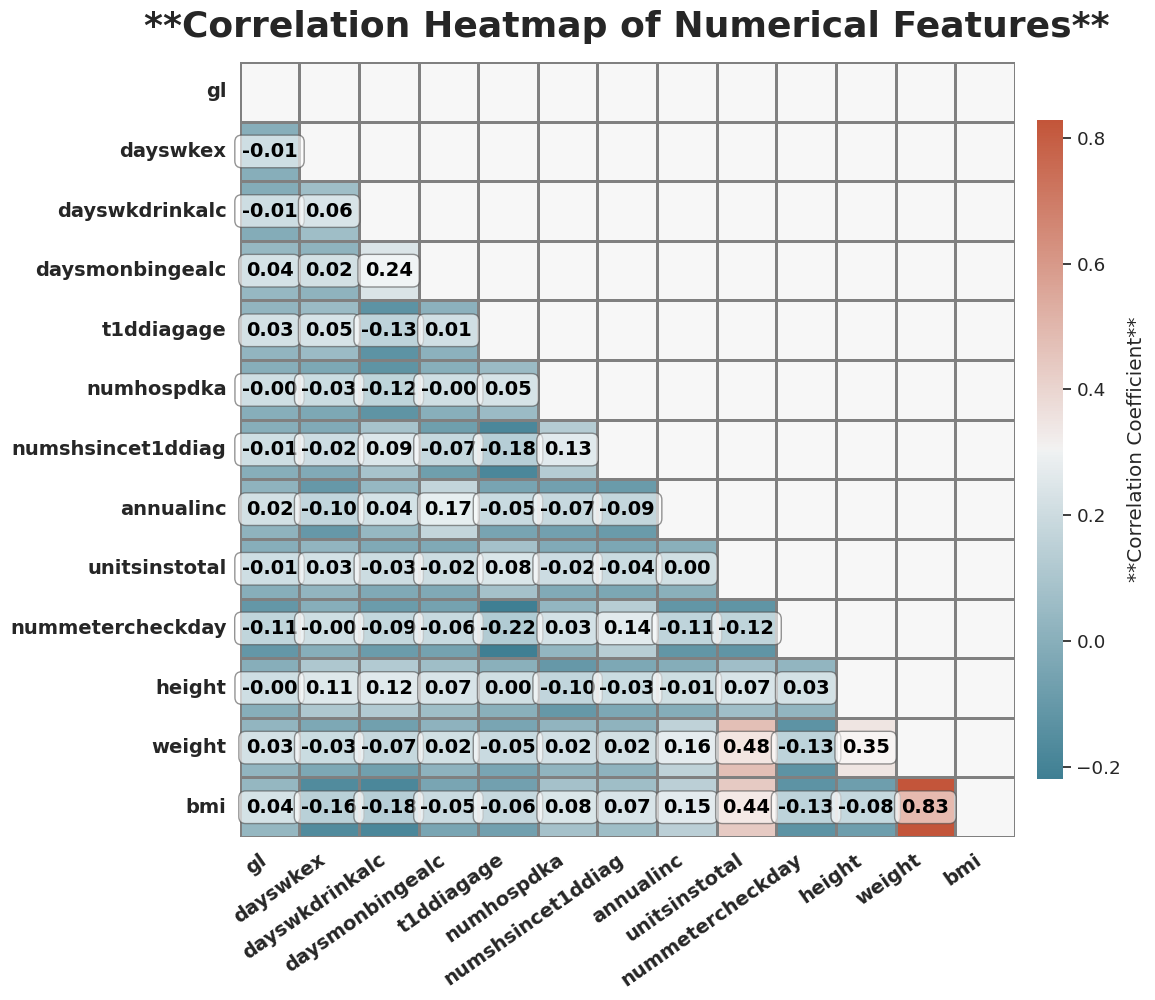

In [13]:
plot_cols = [col for col in numerical_columns if col.lower() != 'id']
corr_matrix = df[plot_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

diverging_cmap = sns.diverging_palette(220, 20, as_cmap=True)

cbar_config = {
    "shrink": 0.85,
    'label': '**Correlation Coefficient**',
    'aspect': 25,
    'pad': 0.02
}

annotation_config = {
    'size': 14,
    'weight': 'bold',
    'color': 'black',
    'bbox': dict(
        boxstyle='round,pad=0.35',
        facecolor='white',
        edgecolor='0.3',
        alpha=0.6
    )
}

heatmap_params = {
    'mask': mask,
    'annot': True,
    'fmt': ".2f",
    'cmap': diverging_cmap,
    'linewidths': 1.8,
    'linecolor': 'grey',
    'square': True,
    'cbar_kws': cbar_config,
    'annot_kws': annotation_config
}

fig, ax = plt.subplots(figsize=(14, 11))
sns.set(style="white", font_scale=1.2)

sns.heatmap(corr_matrix, ax=ax, **heatmap_params)

ax.set_title("**Correlation Heatmap of Numerical Features**", fontsize=26, fontweight='bold', pad=18)
ax.set_facecolor('#F7F7F7')

plt.xticks(fontsize=14, fontweight='bold', rotation=35, ha='right')
plt.yticks(fontsize=14, fontweight='bold', rotation=0)

plt.tight_layout(pad=3)
plt.show()

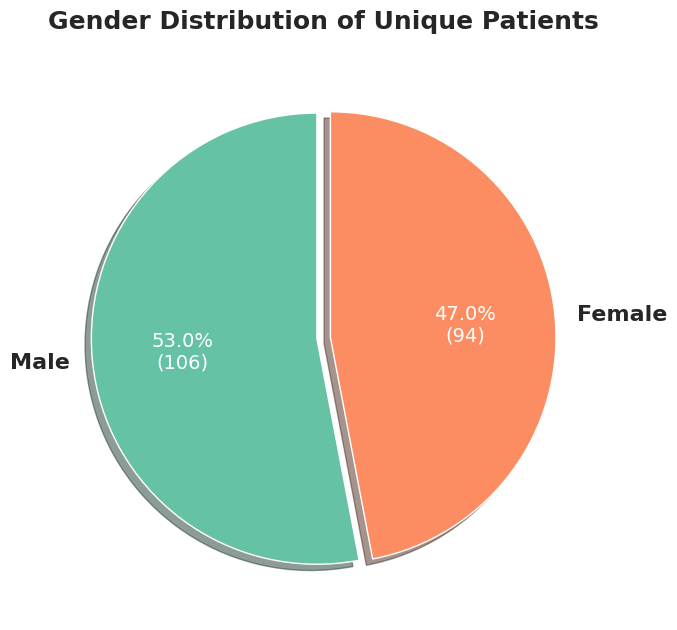

In [14]:
# --- Data Preparation ---
df['gender'] = df['gender'].astype(str).str.strip().str.lower()

GENDER_MAP = {
    'male': 'Male',
    'm': 'Male',
    'female': 'Female',
    'f': 'Female'
}

df['gender'] = df['gender'].map(GENDER_MAP).fillna('Other')

patient_gender = df.drop_duplicates('id')[['id', 'gender']]
gender_counts = patient_gender['gender'].value_counts()

present_labels = gender_counts.index.tolist()
present_values = gender_counts.values

# --- Helper Function ---
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return '{:.1f}%\n({:d})'.format(pct, count)
    return my_autopct

# --- Plotting ---
def plot_gender_distribution(labels, values):
    color_palette = sns.color_palette("Set2", n_colors=len(labels))

    pie_config = dict(
        labels=labels,
        colors=color_palette,
        autopct=make_autopct(values),
        startangle=90,
        explode=[0.03] * len(values),
        shadow=True,
        textprops={'fontsize': 14, 'weight': 'bold'}
    )

    fig, ax = plt.subplots(figsize=(7, 7))
    patches, texts, autotexts = ax.pie(values, **pie_config)

    plt.setp(texts, size=16, weight='bold')
    plt.setp(autotexts, size=14, weight='normal', color='white')

    ax.set_aspect('equal')
    ax.set_title('Gender Distribution of Unique Patients', fontsize=18, weight='bold', pad=20)

    plt.tight_layout()
    plt.show()

# --- Entry Point ---
if len(present_values) == 0:
    print("No valid gender information found for patients.")
else:
    plot_gender_distribution(present_labels, present_values)

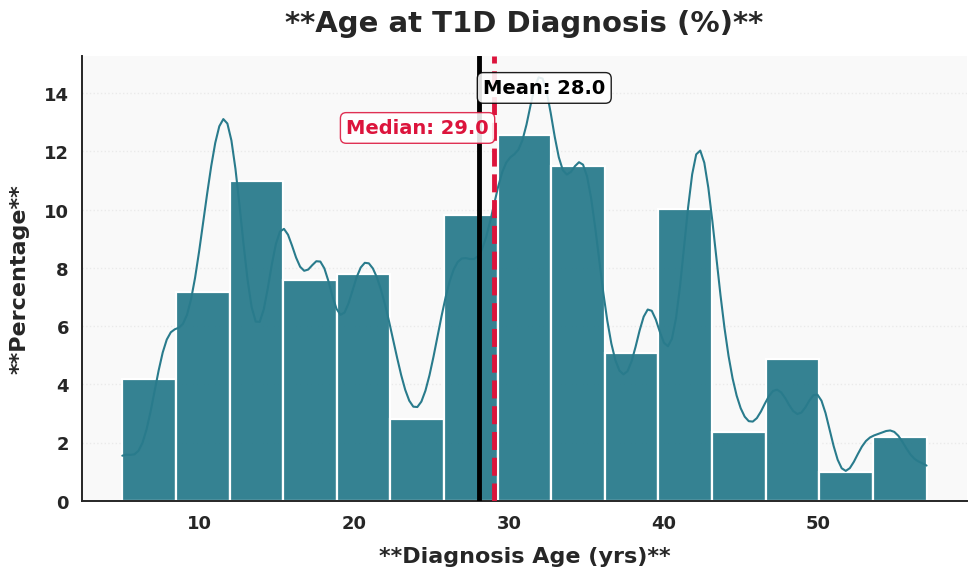

In [15]:
# --- Config ---
MAIN_COLOR = sns.color_palette("crest", n_colors=15)[8]
STAT_STYLES = {
    'mean':   {'color': 'black',   'linestyle': '-',  'label': 'Mean'},
    'median': {'color': 'crimson', 'linestyle': '--', 'label': 'Median'},
}
ANNOTATION_BBOX = dict(boxstyle='round,pad=0.3', alpha=0.88)
LINE_WIDTH = 3.5

# --- Stats ---
stats = {
    'mean':   df['t1ddiagage'].mean(),
    'median': df['t1ddiagage'].median(),
}

# --- Helper ---
def add_stat_annotation(ax, x_pos, y_frac, label, value, style, ha):
    _, ymax = ax.get_ylim()
    ax.text(
        x_pos, ymax * y_frac,
        f"{label}: {value:.1f}",
        color=style['color'],
        fontsize=14,
        fontweight='bold',
        va='top',
        ha=ha,
        bbox={**ANNOTATION_BBOX, 'facecolor': 'white', 'edgecolor': style['color']}
    )

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#F9F9F9')

sns.histplot(
    df['t1ddiagage'],
    bins=15,
    kde=True,
    stat='percent',
    color=MAIN_COLOR,
    edgecolor='white',
    linewidth=1.6,
    alpha=0.94,
    ax=ax
)

for key, style in STAT_STYLES.items():
    ax.axvline(stats[key], color=style['color'], linestyle=style['linestyle'],
               linewidth=LINE_WIDTH, zorder=3)

add_stat_annotation(ax, stats['mean']   + 0.3, 0.95, 'Mean',   stats['mean'],   STAT_STYLES['mean'],   ha='left')
add_stat_annotation(ax, stats['median'] - 0.3, 0.86, 'Median', stats['median'], STAT_STYLES['median'], ha='right')

ax.set_title("**Age at T1D Diagnosis (%)**",  fontsize=21, fontweight='bold', pad=18)
ax.set_xlabel("**Diagnosis Age (yrs)**",       fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel("**Percentage**",                fontsize=16, fontweight='bold', labelpad=10)

plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.32, linewidth=1)

sns.despine()
ax.spines['bottom'].set_linewidth(1.4)
ax.spines['left'].set_linewidth(1.4)

plt.tight_layout()
plt.show()

/tmp/ipykernel_55/2101849850.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df_plot.groupby('age_bin').agg(


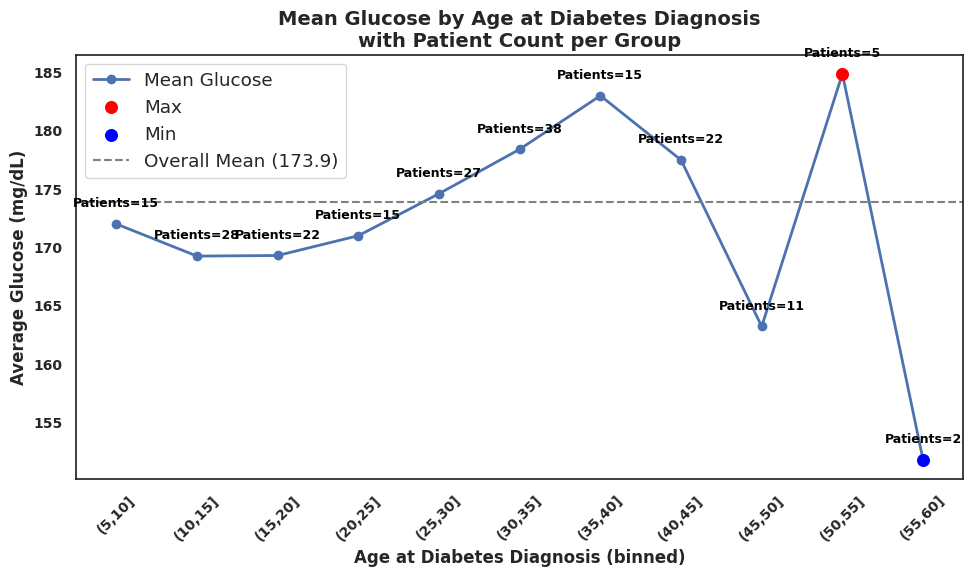

In [17]:
df_plot = df[['id', 't1ddiagage', 'gl']].dropna()

# ----- Bin ages (5–60 in 5-year bins) -----
bins = list(range(5, 65, 5))
labels = [f"({bins[i]},{bins[i+1]}]" for i in range(len(bins)-1)]
df_plot['age_bin'] = pd.cut(df_plot['t1ddiagage'], bins=bins, labels=labels, include_lowest=True)

# ----- Aggregate by bin -----
g = df_plot.groupby('age_bin').agg(
    mean_gl=('gl', 'mean'),
    patient_count=('id', 'nunique'),
    datapoints=('gl', 'count')
).reset_index()

# ----- Plot -----
plt.figure(figsize=(10,6))
plt.plot(g['age_bin'], g['mean_gl'], marker='o', linewidth=2, label="Mean Glucose")

# Annotate patient counts (bold)
for i, (x, y, p) in enumerate(zip(g['age_bin'], g['mean_gl'], g['patient_count'])):
    plt.text(i, y+1.5, f"Patients={p}", ha='center', fontsize=9, fontweight='bold', color="black")

# Highlight min/max bins
ymax, ymin = g['mean_gl'].max(), g['mean_gl'].min()
xmax = g.loc[g['mean_gl'].idxmax(), 'age_bin']
xmin = g.loc[g['mean_gl'].idxmin(), 'age_bin']
plt.scatter(xmax, ymax, s=70, color='red', zorder=3, label="Max")
plt.scatter(xmin, ymin, s=70, color='blue', zorder=3, label="Min")

# Overall mean line
overall = df_plot['gl'].mean()
plt.axhline(overall, color='gray', linestyle='--', label=f"Overall Mean ({overall:.1f})")

# Cosmetics
plt.title("Mean Glucose by Age at Diabetes Diagnosis\nwith Patient Count per Group", fontsize=14, fontweight='bold')
plt.xlabel("Age at Diabetes Diagnosis (binned)", fontsize=12, fontweight='bold')
plt.ylabel("Average Glucose (mg/dL)", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_55/840744445.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset, shade=True, color=colors[gender], label=gender, linewidth=2)
/tmp/ipykernel_55/840744445.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset, shade=True, color=colors[gender], label=gender, linewidth=2)


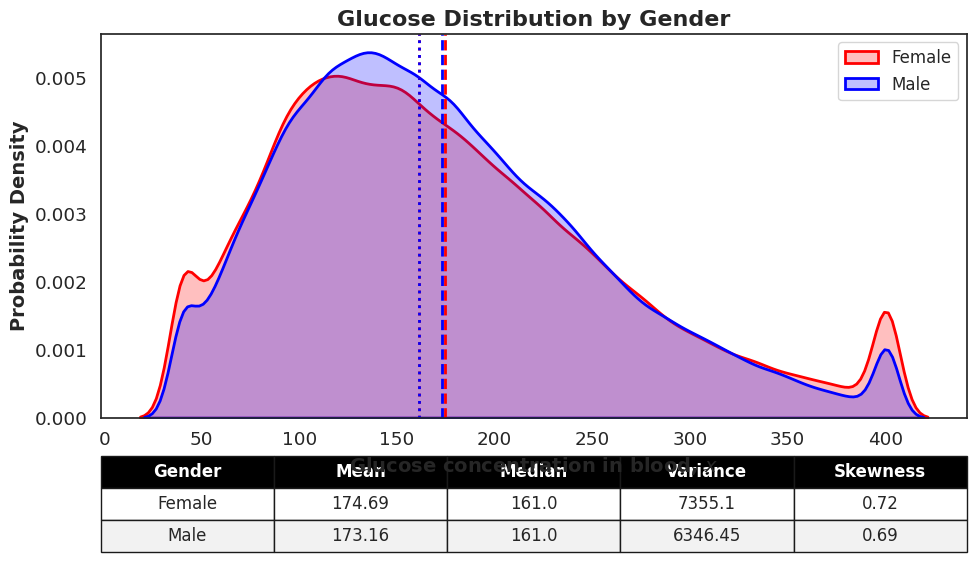

In [18]:
df['gender'] = df['gender'].astype(str).str.strip().str.title()

# Prepare stats by gender
stats = df.groupby('gender')['gl'].agg(['mean', 'median', 'var']).reset_index()
stats['skewness'] = df.groupby('gender')['gl'].apply(lambda x: skew(x, nan_policy='omit')).values
stats_display = stats.copy()
stats_display.columns = ['Gender', 'Mean', 'Median', 'Variance', 'Skewness']
stats_display = stats_display.round(2)

# Colors for genders
colors = {'Male': 'blue', 'Female': 'red'}

# ----- Plot KDE -----
fig, ax = plt.subplots(figsize=(10,6))

for gender in stats['gender']:
    subset = df[df['gender'] == gender]['gl'].dropna()
    sns.kdeplot(subset, shade=True, color=colors[gender], label=gender, linewidth=2)
    
    # Mean line (dashed)
    ax.axvline(stats.loc[stats['gender'] == gender, 'mean'].values[0],
               color=colors[gender], linestyle='--', linewidth=2)
    # Median line (dotted)
    ax.axvline(stats.loc[stats['gender'] == gender, 'median'].values[0],
               color=colors[gender], linestyle=':', linewidth=2)

ax.set_xlabel(r'Glucose concentration in blood, $x$', fontsize=14, weight='bold')
ax.set_ylabel('Probability Density', fontsize=14, weight='bold')
ax.set_title('Glucose Distribution by Gender', fontsize=16, weight='bold')
ax.legend(fontsize=12, frameon=True)

plt.tight_layout(rect=[0,0.15,1,1])  # leave space for table

# ----- Add Table Below Plot -----
table = plt.table(
    cellText=stats_display.values,
    colLabels=stats_display.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0.0, -0.35, 1, 0.25]  # [left, bottom, width, height]
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)

# Bold headers + cells
for (row, col), cell in table.get_celld().items():
    if row == 0:  # header row
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('black')
    else:
        cell.set_facecolor('#f2f2f2' if row % 2 == 0 else 'white')

plt.show()

In [19]:
df.shape

(647858, 42)

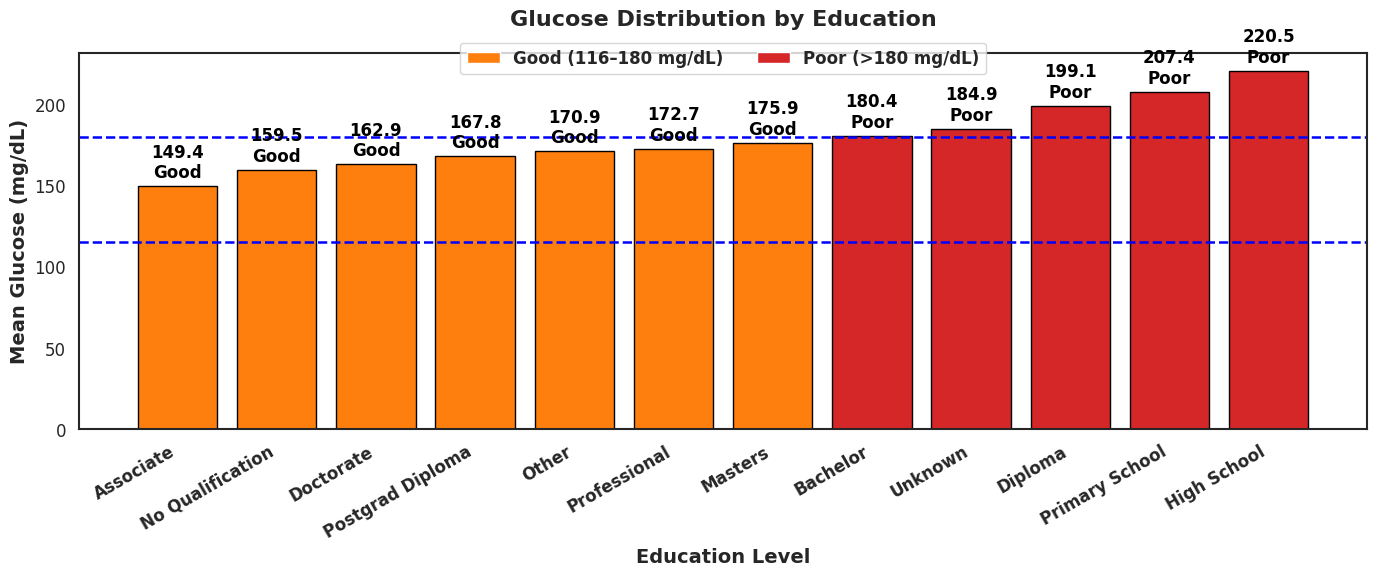

In [20]:
from matplotlib.patches import Patch

# Suggested mapping for EduLevel (0-11) to human-readable labels
edu_map = {
    0: "No Qualification",
    1: "Primary School",
    2: "High School",
    3: "Diploma",
    4: "Associate",
    5: "Bachelor",
    6: "Masters",
    7: "Postgrad Diploma",
    8: "Doctorate",
    9: "Professional",
    10: "Other",
    11: "Unknown"
}

df["edu_name"] = df["edulevel"].map(edu_map).fillna("Unknown")

# Aggregate mean glucose per education level
edu_glucose = (
    df.groupby("edu_name")["gl"]
      .mean()
      .reset_index()
      .rename(columns={"gl": "mean_glucose"})
)

# Categorize glucose status
def categorize_glucose(val):
    if val <= 115:
        return "Excellent"
    elif val <= 180:
        return "Good"
    else:
        return "Poor"

edu_glucose["Glucose_Status"] = edu_glucose["mean_glucose"].apply(categorize_glucose)

# Sort by mean_glucose ascending to resemble example plot
edu_glucose = edu_glucose.sort_values("mean_glucose").reset_index(drop=True)

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(edu_glucose))

# Colors
color_map = {"Excellent":"#2ca02c", "Good":"#ff7f0e", "Poor":"#d62728"}
edu_glucose["Color"] = edu_glucose["Glucose_Status"].map(color_map).fillna("#888888")

# Bars
ax.bar(x, edu_glucose["mean_glucose"], color=edu_glucose["Color"], edgecolor="black")

# Labels above bars
for xi, val, status in zip(x, edu_glucose["mean_glucose"], edu_glucose["Glucose_Status"]):
    ax.text(xi, val + 3, f"{val:.1f}\n{status}", ha="center", va="bottom",
            fontsize=12, fontweight="bold", color="black")

# Axes & title
ax.set_xticks(list(x))
ax.set_xticklabels(edu_glucose["edu_name"], rotation=30, ha="right", fontsize=12, fontweight="bold")
ax.set_ylabel("Mean Glucose (mg/dL)", fontsize=14, fontweight="bold")
ax.set_xlabel("Education Level", fontsize=14, fontweight="bold")
ax.set_title("Glucose Distribution by Education", fontsize=16, fontweight="bold", pad=20)

# Reference lines
ax.axhline(115, linestyle="--", linewidth=1.8, color="blue")
ax.axhline(180, linestyle="--", linewidth=1.8, color="blue")

# Spines & ticks
for spine in ["bottom", "left", "top", "right"]:
    ax.spines[spine].set_linewidth(1.5)
ax.tick_params(axis="x", labelsize=12, width=1.5, length=6)
ax.tick_params(axis="y", labelsize=12, width=1.5, length=6)

# Legend
labels_map = {
    "Excellent": "Excellent (≤115 mg/dL)",
    "Good": "Good (116–180 mg/dL)",
    "Poor": "Poor (>180 mg/dL)"
}
statuses_present = [s for s in ["Excellent","Good","Poor"] if s in set(edu_glucose["Glucose_Status"])]
legend_elements = [Patch(facecolor=color_map[s], label=labels_map[s]) for s in statuses_present]
leg = ax.legend(handles=legend_elements, fontsize=12, ncol=len(statuses_present),
                loc="upper center", bbox_to_anchor=(0.5, 1.05), frameon=True)
for text in leg.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()

In [16]:
df.shape

(647858, 42)

/tmp/ipykernel_55/2530629499.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_55/2530629499.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels, **TICK_STYLE, rotation=0, ha='center')
/tmp/ipykernel_55/2530629499.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{int(t)}" for t in ax.get_yticks()], **TICK_STYLE)


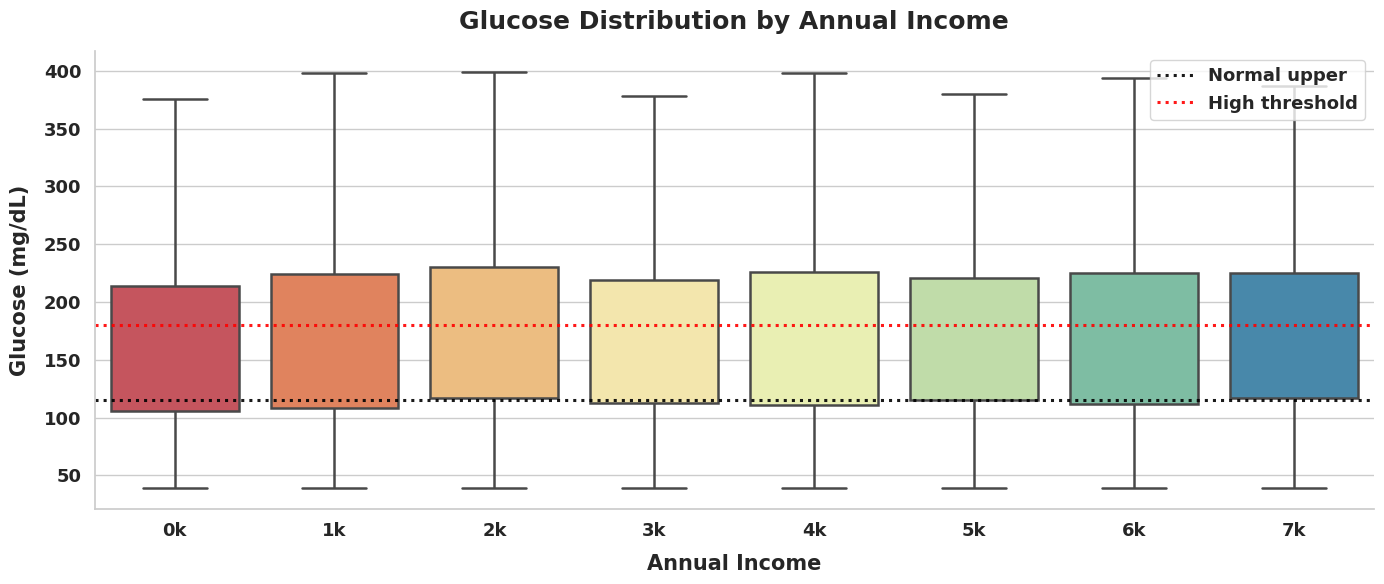

In [22]:
# --- Config ---
THRESHOLDS = [
    {'y': 115, 'color': 'black', 'label': 'Normal upper'},
    {'y': 180, 'color': 'red',   'label': 'High threshold'},
]
LINE_STYLE = {'linestyle': ':', 'linewidth': 2.2, 'alpha': 0.9}

BOXPLOT_PROPS = {
    'whiskerprops': {'linewidth': 1.8},
    'boxprops':     {'linewidth': 1.8},
    'capprops':     {'linewidth': 1.8},
}

TICK_STYLE   = {'fontsize': 13, 'fontweight': 'bold'}
LABEL_STYLE  = {'fontsize': 15, 'fontweight': 'bold'}
TITLE_STYLE  = {'fontsize': 18, 'fontweight': 'bold', 'pad': 16}

# --- Data Prep ---
d_plot = df.copy()
d_plot['inc_k_1k'] = d_plot['annualinc'].astype(int)

order        = sorted(d_plot['inc_k_1k'].unique())
xtick_labels = [f"{k}k" for k in order]

# --- Helper ---
def apply_bold_legend(ax):
    legend = ax.legend(fontsize=13, frameon=True, loc='upper right')
    for text in legend.get_texts():
        text.set_fontweight('bold')

# --- Plot ---
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=d_plot,
    x='inc_k_1k',
    y='gl',
    showfliers=False,
    showmeans=False,
    medianprops={'visible': False},
    palette='Spectral',
    order=order,
    ax=ax,
    **BOXPLOT_PROPS
)

for threshold in THRESHOLDS:
    ax.axhline(threshold['y'], color=threshold['color'],
               label=threshold['label'], **LINE_STYLE)

ax.set_title("Glucose Distribution by Annual Income", **TITLE_STYLE)
ax.set_xlabel("Annual Income",    **LABEL_STYLE, labelpad=10)
ax.set_ylabel("Glucose (mg/dL)", **LABEL_STYLE, labelpad=10)

ax.set_xticklabels(xtick_labels, **TICK_STYLE, rotation=0, ha='center')
ax.set_yticklabels([f"{int(t)}" for t in ax.get_yticks()], **TICK_STYLE)

apply_bold_legend(ax)

sns.despine()
plt.tight_layout()
plt.show()

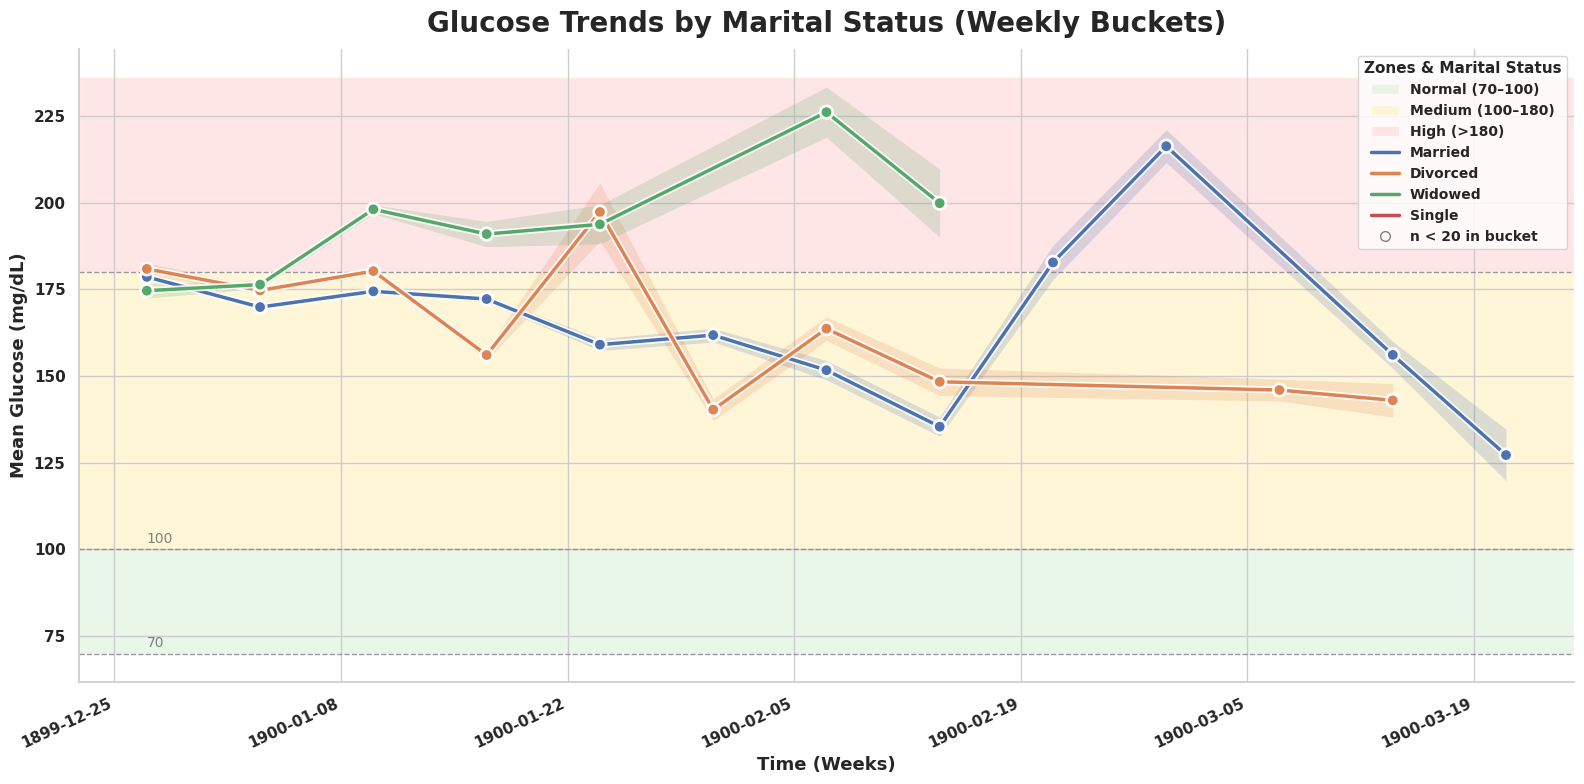

In [23]:
import matplotlib.dates as mdates   
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# Parse time and build week buckets
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df = df.dropna(subset=["time", "gl"])

# Week start (Mon) index & actual week-start date for x-axis
week0 = df["time"].min().normalize()
df["week"] = ((df["time"] - week0).dt.days // 7).astype(int)
df["week_start"] = week0 + pd.to_timedelta(df["week"] * 7, unit="D")

# Keep only the 4 statuses shown in the sample (if present)
keep_status = ["Married", "Divorced", "Widowed", "Single"]
df = df[df["maritalstatus"].isin(keep_status)]

# Aggregate by maritalstatus x week
agg = (
    df.groupby(["maritalstatus", "week", "week_start"])["gl"]
      .agg(["mean", "count", "std"]).reset_index()
)
agg["ci95"] = 1.96 * (agg["std"] / np.sqrt(agg["count"].clip(lower=1)))
agg["ci95"] = agg["ci95"].fillna(0)

# Plot
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(16, 8))

# Risk zones
ymax = max(220, float(agg["mean"].max()) if not agg.empty else 220) + 10
zones = [
    (70, 100, '#d9f2d9', 'Normal (70–100)'),
    (100, 180, '#fff1bf', 'Medium (100–180)'),
    (180, ymax, '#ffd6d6', 'High (>180)'),
]
for lo, hi, color, _ in zones:
    ax.axhspan(lo, hi, facecolor=color, alpha=0.6, zorder=0)

# Reference lines with labels "70" and "100" on the left
for y, lab in [(70, "70"), (100, "100"), (180, None)]:
    ax.axhline(y, linewidth=1.0, linestyle='--', color='gray', alpha=0.8, zorder=1)
    if lab is not None:
        # place text near the left side
        ax.text(agg["week_start"].min() if not agg.empty else week0, y+1, lab,
                va='bottom', ha='left', fontsize=10, color='gray')

# Colors consistent and pleasant
palette = sns.color_palette("deep", n_colors=len(keep_status))
color_map = dict(zip(keep_status, palette))

# Lines + CI + hollow markers where n<20
for status in keep_status:
    sub = agg[agg["maritalstatus"] == status].sort_values("week_start").copy()
    if sub.empty:
        continue

    x = sub["week_start"].to_numpy()
    mean = sub["mean"].astype(float).to_numpy()
    ci = sub["ci95"].astype(float).to_numpy()

    ax.fill_between(x, np.clip(mean - ci, 0, None), mean + ci,
                    alpha=0.2, color=color_map[status], linewidth=0)
    ax.plot(x, mean, color=color_map[status], marker='o', linewidth=2.5, zorder=3,
            path_effects=[pe.Stroke(linewidth=5.0, foreground='white', alpha=0.9), pe.Normal()],
            label=status)

    sparse = sub["count"].to_numpy() < 20
    if sparse.any():
        ax.scatter(x[sparse], mean[sparse], s=60, facecolors='none',
                   edgecolors=color_map[status], linewidths=2, zorder=4)

# Title & labels
ax.set_title("Glucose Trends by Marital Status (Weekly Buckets)", fontsize=20, fontweight='bold', pad=12)
ax.set_xlabel("Time (Weeks)", fontsize=13, fontweight='bold')
ax.set_ylabel("Mean Glucose (mg/dL)", fontsize=13, fontweight='bold')

# Date formatter on x-axis to show as YYYY-MM-DD like the sample
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=11, fontweight='bold')
plt.setp(ax.get_yticklabels(), fontsize=11, fontweight='bold')

# Legend: zones + four statuses + hollow marker
zone_patches = [Patch(facecolor=c, alpha=0.6, label=lab) for (_,_,c,lab) in zones]
status_lines = [Line2D([0],[0], color=color_map[s], lw=2.5, label=s) for s in keep_status]
hollow = Line2D([0],[0], marker='o', color='gray', lw=0, markerfacecolor='none', markersize=7, label='n < 20 in bucket')
leg = ax.legend(handles=zone_patches + status_lines + [hollow],
                title="Zones & Marital Status", frameon=True, fontsize=10, title_fontsize=11,
                loc="upper right")
for t in leg.get_texts():
    t.set_fontweight('bold')
leg.get_title().set_fontweight('bold')

sns.despine(left=False, bottom=False)
plt.tight_layout()

In [24]:
df.shape

(590235, 45)

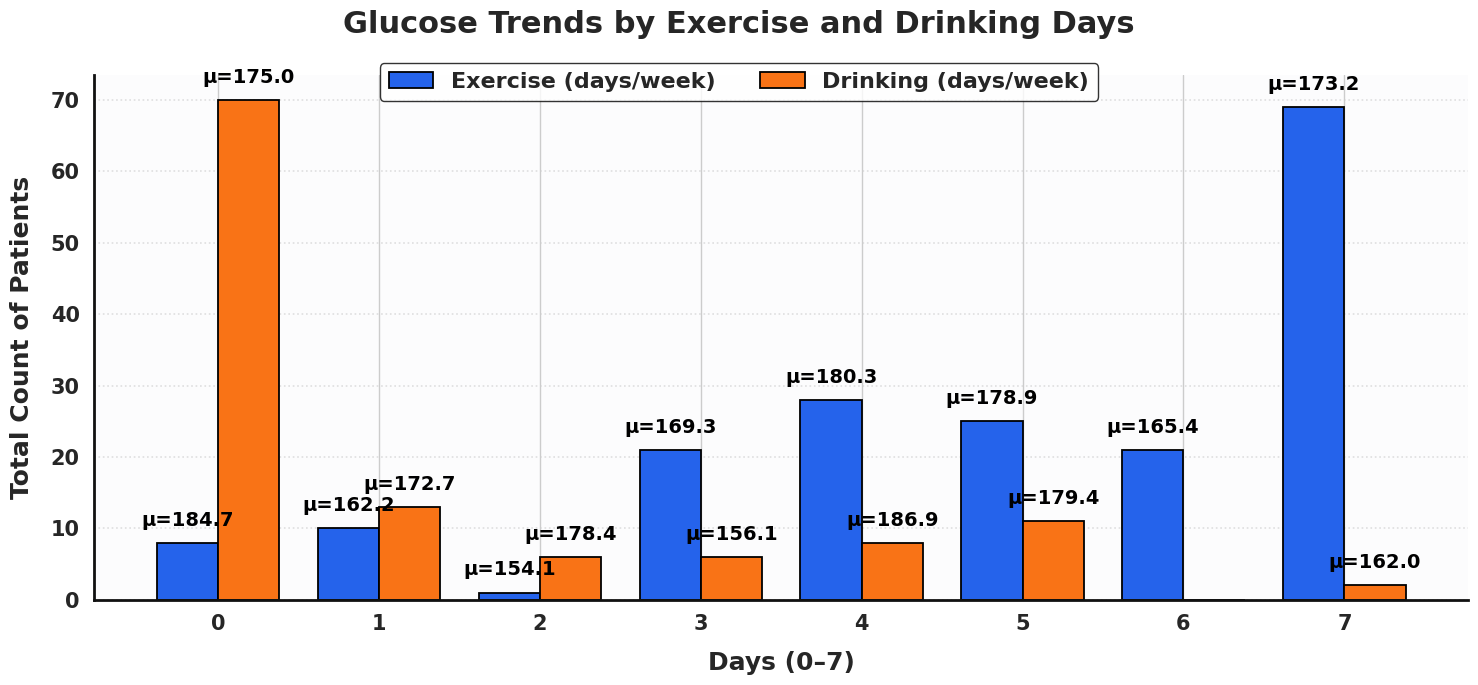

In [25]:
ex_agg = (
    df.groupby("dayswkex")
      .agg(count=("id", "nunique"),        # unique patients
           mean_glucose=("gl", "mean"))    # mean glucose
      .reset_index()
)

# For Drinking
alc_agg = (
    df.groupby("dayswkdrinkalc")
      .agg(count=("id", "nunique"),        # unique patients
           mean_glucose=("gl", "mean"))
      .reset_index()
)

# Ensure full 0–7 days are present
full_index = pd.DataFrame({"days": np.arange(8)})
ex_agg = full_index.merge(ex_agg, left_on="days", right_on="dayswkex", how="left").drop(columns="dayswkex")
alc_agg = full_index.merge(alc_agg, left_on="days", right_on="dayswkdrinkalc", how="left").drop(columns="dayswkdrinkalc")

plt.rcParams.update({
    "axes.edgecolor": "#111",
    "axes.linewidth": 2.0,   # thicker
    "font.size": 14          # base font bigger
})

fig, ax = plt.subplots(figsize=(15,7))
ax.set_facecolor("#fcfcfd")

x = np.arange(8); width = 0.38
b1 = ax.bar(x - width/2, ex_agg["count"].fillna(0), width,
            color="#2563eb", edgecolor="black", linewidth=1.3,
            label="Exercise (days/week)")
b2 = ax.bar(x + width/2, alc_agg["count"].fillna(0), width,
            color="#f97316", edgecolor="black", linewidth=1.3,
            label="Drinking (days/week)")

# --- Annotate with mean values ---
def annotate(bars, means):
    ymax = max(ax.get_ylim()[1], (ex_agg["count"].max() or 1))
    for bar, m in zip(bars, means):
        if pd.notna(m):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+ymax*0.025,
                    f"µ={m:.1f}",
                    ha="center", va="bottom",
                    fontsize=14, fontweight="bold", color="black")

annotate(b1, ex_agg["mean_glucose"].values)
annotate(b2, alc_agg["mean_glucose"].values)

# --- Axis labels & ticks ---
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in x], fontsize=15, fontweight="bold")
ax.set_xlabel("Days (0–7)", fontsize=18, fontweight="bold", labelpad=12)
ax.set_ylabel("Total Count of Patients", fontsize=18, fontweight="bold", labelpad=12)

ax.tick_params(axis="x", labelsize=15, width=2, length=7)
ax.tick_params(axis="y", labelsize=15, width=2, length=7)
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight("bold")

# --- Title & Legend ---
fig.suptitle("Glucose Trends by Exercise and Drinking Days",
             fontsize=22, fontweight="bold", y=0.98)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center", bbox_to_anchor=(0.5, 0.92),
           ncol=2, frameon=True, edgecolor="black",
           prop={"weight":"bold", "size":16})

plt.subplots_adjust(top=0.80)  # leave space for title + legend

# --- Grid & spines ---
ax.grid(axis="y", linestyle=":", alpha=0.6, linewidth=1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()